In [1]:
import sklearn
from sklearn.datasets import load_wine
import pennylane as qml
from pennylane import numpy as np
from sklearn.model_selection import train_test_split
from pennylane.optimize import AdamOptimizer
import matplotlib.pyplot as plt

In [6]:
# We apply normalization to rescale these attributes to the interval [0, π]. The labels are remapped from {0, 1} to {−1, 1} to align with the output range of the quantum circuit model
def func():
    wine = load_wine()
    x,y = wine.data, wine.target
    x_scaled = np.pi*(x-np.min(x,axis=0,keepdims=True))/np.ptp(x,axis=0,keepdims=True)
    y = y*2 - 1
    index_c0 = y == -1
    index_c1 = y == 1
    x_filtered = np.concatenate((x_scaled[index_c0],x_scaled[index_c1]), axis=0)
    y_filtered = np.concatenate((y[index_c0],y[index_c1]), axis=0)
    x_train , x_test , y_train , y_test = train_test_split(x_filtered,y_filtered,test_size =0.2 , random_state=42)
    return x_train , x_test , y_train , y_test

x_train , x_test , y_train , y_test = func()

In [7]:
# angle encoding followed by a layer of CNOT gates acting on neighboring qubits to introduce entanglement
def encoding(x):
    n_qubit = len(x)
    qml.AngleEmbedding(features=x, wires=range(n_qubit),rotation="X")
    for i in range ( n_qubit ):
        if i+1 < n_qubit :
           qml. CNOT ( wires =[i, i +1])
    #return qml.state()

In [8]:
# To read-out the category information of each input sample from the prepared quantum state, we compute the expectation value of the Pauli-Z operator on the first qubit
def classifier(param, x): # param is optimized during training
    encoding(x)
    n_layer, n_qubit = param.shape[0], param.shape[1]
    for i in range(n_layer):
        for j in range(n_qubit):
            qml.Rot(param[i,j,0], param[i,j,1], param[i,j,2], wires=j) # every qubit gets its own three trainable rotation parameters in every layer
            if j+1 < n_qubit:
                qml.CNOT(wires=[j,j+1])
    return qml.expval(qml.PauliZ(0))
n_qubit = x_train.shape[1]
dev = qml.device('default.qubit', wires=n_qubit)
circuit = qml.QNode(classifier,dev) # creates a QNode that connects your quantum circuit/function classifier to the quantum device dev

In [9]:
param=np.pi*np.random.randn(2,n_qubit,3)
classifier(param,x_train[1])

expval(Z(0))

C:\Users\HP\AppData\Local\Temp\ipykernel_2752\3501637099.py:2: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


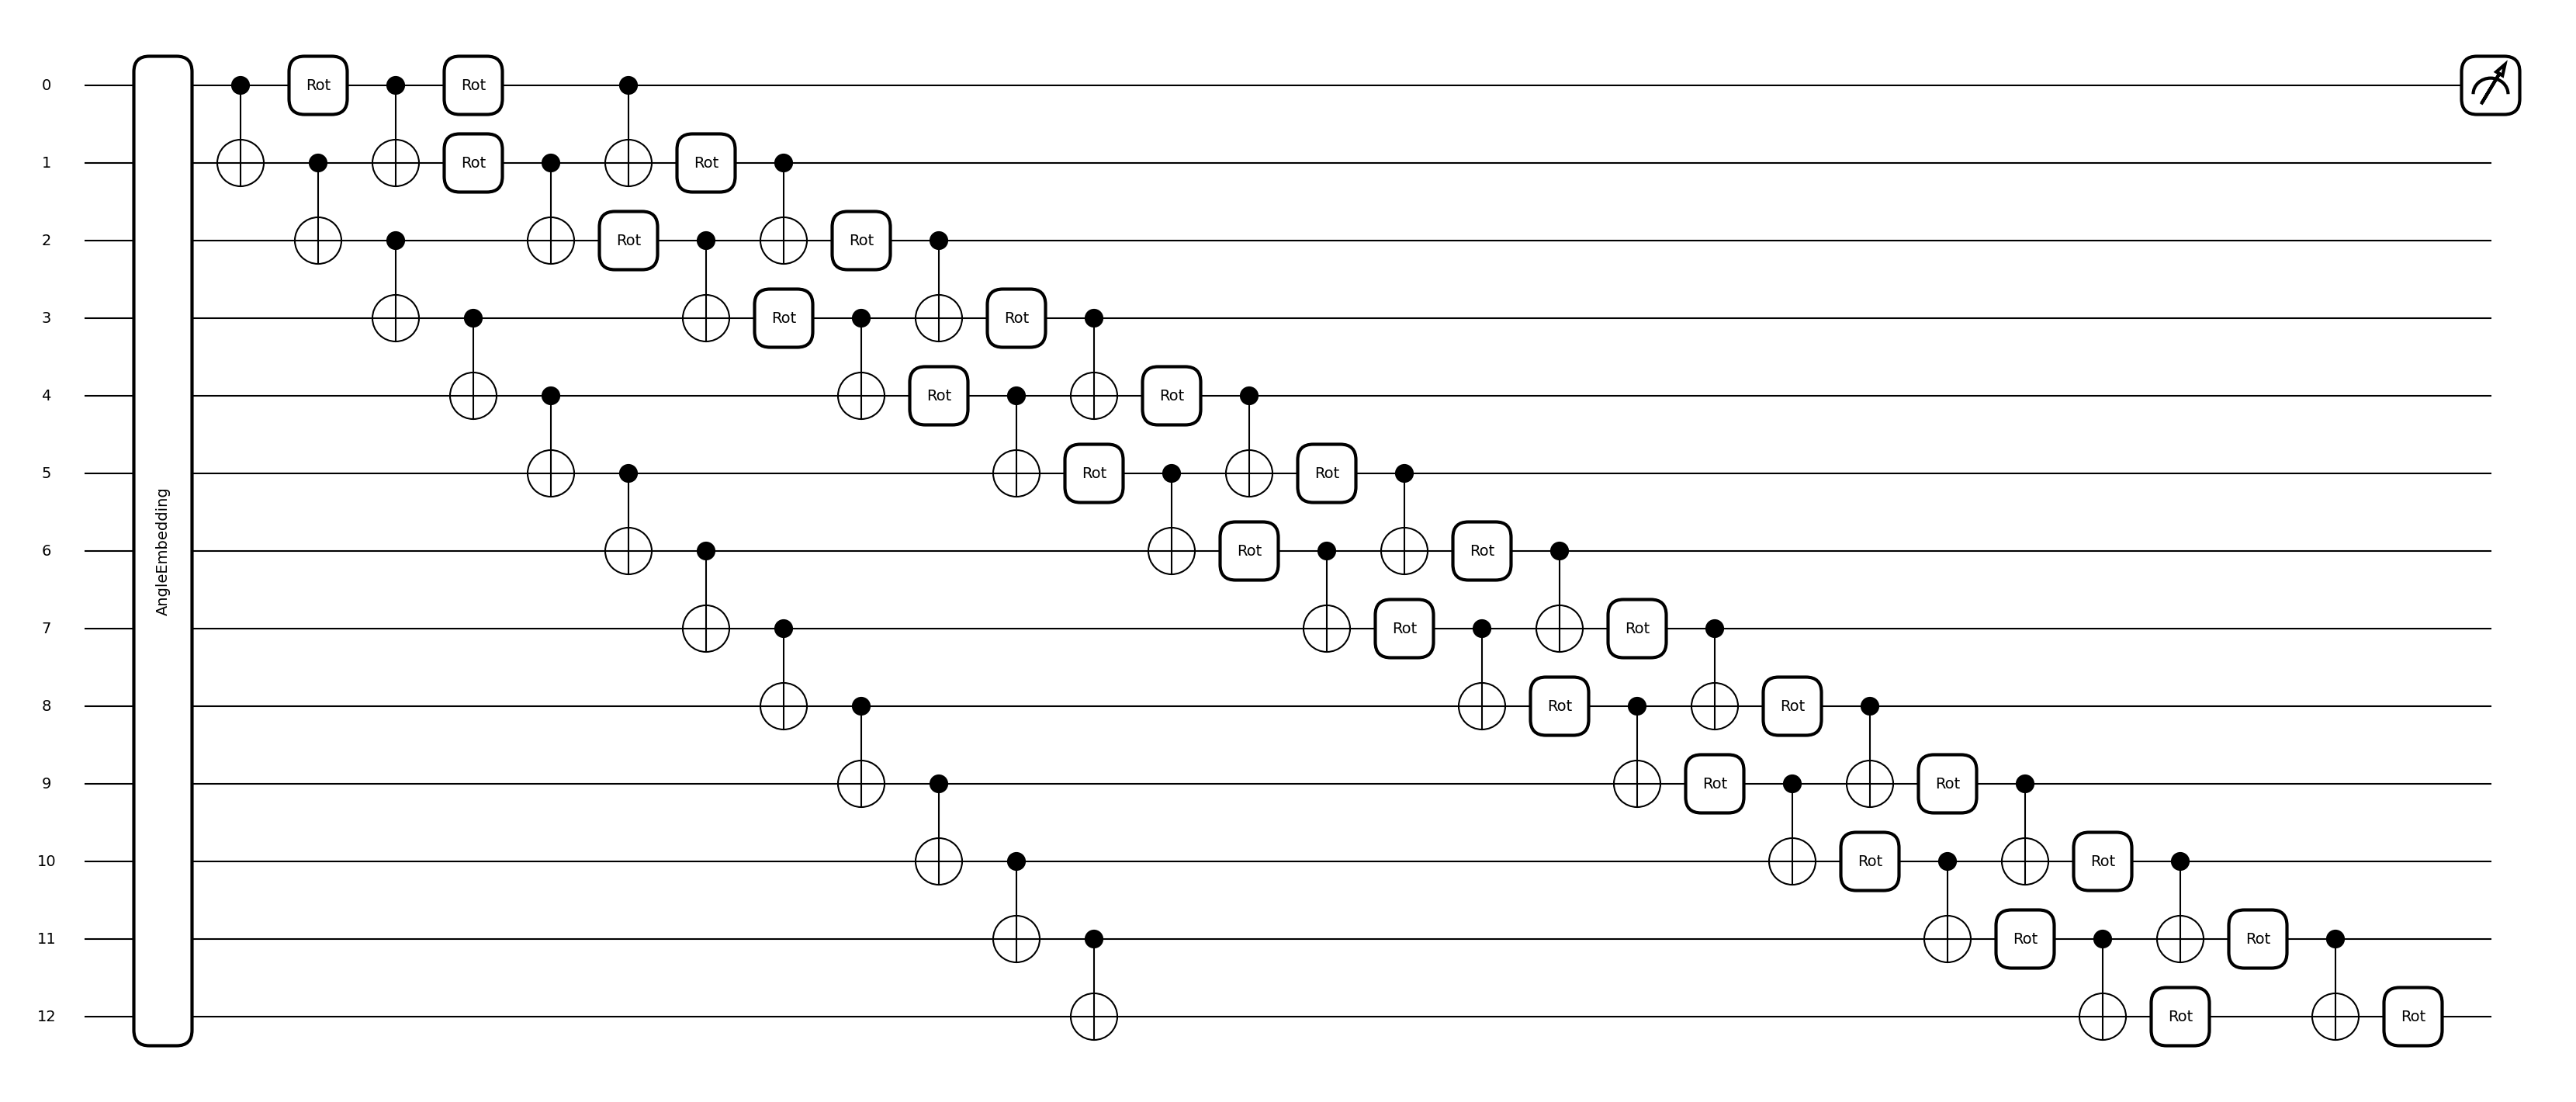

In [10]:
fig, ax = qml.draw_mpl(circuit)(np.pi*np.random.randn(2,n_qubit,3), x_train[0])
fig.show()

In [11]:
def mse_loss(predict,label):
    return np.mean((predict-label)**2)

def cost(param,circuit,x,y):
    exp = []
    for i in range(len(x)):
        pred = circuit(param,x=x[i])
        exp.append(pred)
        return mse_loss(np.array(exp),y)
# accuracy is then calculated as the proportion of correctly classified samples out of the total
# At the end of each epoch, both the training and test losses, along with the classification accuracy, are recorded to track the model's performance
def accuracy(predict,label):
    return np.sum((np.sign(predict)*label+1)/2)/len(predict)
param=np.pi*np.random.randn(2,n_qubit,3)

exp = []
for i in range(len(x_train)):
    pred = circuit(param,x=x_train[i])
    exp.append(pred)
accuracy(exp,y_train)

tensor(0.10576923, requires_grad=True)

In [82]:
# Adam optimizer is used to minimize the loss function
lr = 0.01
opt = AdamOptimizer(lr)
batch_size = 4
n_epoch = 50
cost_train,cost_test,acc_train,acc_test = [],[],[],[]
for i in range(n_epoch):
    index = np.random.permutation(len(x_train))
    feat_train, label_train = x_train[index], y_train[index]
    for j in range(0,len(x_train),batch_size):
        feat_train_batch = feat_train[j:j+batch_size]
        label_train_batch = label_train[j:j+batch_size]
        param = opt.step(lambda v: cost(v,circuit,feat_train_batch,label_train_batch), param)

    # compute cost   
    cost_train.append(cost(param,circuit,feat_train,label_train))
    cost_test.append(cost(param,circuit,x_test,y_test))

    # compute accuracy
    pred_train = []
    for j in range(len(x_train)):
        pred_train.append(circuit(param, x=x_train[j]))
    acc_train.append(accuracy(np.array(pred_train),y_train))
    pred_test = []
    for j in range(len(x_test)):
        pred_test.append(circuit(param,x=x_test[j]))
    acc_test.append(accuracy(np.array(pred_test),y_test))
    

[tensor(0.89423077, requires_grad=True),
 tensor(0.89903846, requires_grad=True),
 tensor(0.89903846, requires_grad=True),
 tensor(0.89423077, requires_grad=True),
 tensor(0.89903846, requires_grad=True),
 tensor(0.89903846, requires_grad=True),
 tensor(0.90384615, requires_grad=True),
 tensor(0.89903846, requires_grad=True),
 tensor(0.89423077, requires_grad=True),
 tensor(0.89423077, requires_grad=True),
 tensor(0.90384615, requires_grad=True),
 tensor(0.89903846, requires_grad=True),
 tensor(0.89903846, requires_grad=True),
 tensor(0.89423077, requires_grad=True),
 tensor(0.89423077, requires_grad=True),
 tensor(0.89423077, requires_grad=True),
 tensor(0.90384615, requires_grad=True),
 tensor(0.89903846, requires_grad=True),
 tensor(0.90384615, requires_grad=True),
 tensor(0.90384615, requires_grad=True),
 tensor(0.89423077, requires_grad=True),
 tensor(0.89903846, requires_grad=True),
 tensor(0.89903846, requires_grad=True),
 tensor(0.90384615, requires_grad=True),
 tensor(0.899038